# Reglas de asociación
#### Mineria de Datos
##### Por Johel Santiago Arias Becerra

Enlace del analisis y justificacion

https://1drv.ms/w/c/9cd239359a0de8d6/IQAfRncL-DsFQIKpGbTDKLU8AV0Ml8s2JtqigWQlydHuxoc?e=yOgCup

In [99]:
# !pip install pandas openpyxl spacy rapidfuzz matplotlib seaborn networkx scikit-learn
# !python -m spacy download es_core_news_sm

Se realiza la importacion de librerías necesarias

In [100]:
# Propósito: importar librerías, definir parámetros globales y preparar el entorno del análisis.
from __future__ import annotations

import re
import unicodedata
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns
import spacy
from sklearn.preprocessing import MultiLabelBinarizer

Y se definen los parámetros globales

In [101]:
# ── Configuración global ──────────────────────────────
DATASET_PATH = Path('data/dataset.xlsx')
SHEET_NAME = 'Respuestas de formulario 1'
EDAD_BINS = [0, 18, 25, 30, 60, 100]
EDAD_LABELS = ['Menor de 18', '18-25', '26-30', '31-60', '61+']
OUTPUT_PATH = Path('df_procesado.xlsx')
# ─────────────────────────────────────────────────────

nlp = spacy.load('es_core_news_sm', disable=['parser', 'ner'])

## 1. Carga y descripción de los datos

la fuente de los datos del dataset utilizado se tomaron a partir de una encuenta propia con un total de 200 datos segun lo comentado en clase

Se utilizaron los datos recopilados por el fomulario enviado por el profesor mas informacion adicional recopilada con mi propio formulario

Estos datos fueron exportados a excel y utilizados para las reglas de asociacion

Por lo tanto, inicialmente se lee el dataset en excel para comenzar a trabajar los datos


In [102]:
# Propósito: ubicar la ruta efectiva del dataset y validar su existencia antes de cargarlo.
dataset_file = DATASET_PATH
df = pd.read_excel(dataset_file, sheet_name=SHEET_NAME)
df.head()

,Marca temporal,EDAD,GENERO,ESTRATO NSE,CIUDAD DE ORIGEN,Con quien vive actualmente,Numero de personas en el hogar,Quien realiza las compras en el Hogar,Tu misión de compra es abastecer tu hogar. Con que frecuencia lo haces.,Lugar principal de compra,Presupuesto Mensual aproximado,Alimentos Básicos,Proteinas,Bebidas,Snacks y otros,Delikatessen,Aseo para el Hogar,Aseo Personal,ultima
0,2026-04-01 08:00:00,18,Masculino,E2,Bogotá,Padres,5,Otra persona,Quincenal,"Supermercado (Exito, Jumbo, Etc)",700000,"Pastas, Lentejas",Atun,"Te, Leche",ninguno,ninguno,"Papel Higienico, Suavizantes, Blanqueadores","Talcos, Lociones - Colonias","te, lavaloza, desinfectante, leche, suavizante..."
1,2026-04-01 13:42:00,21,Femenino,E3,Medellín,Padres,4,Otra persona,Mensual,"Hard Discount (D1, ARA, etc )",1000000,"Frijoles, Pastas","Pescados, Pollo, Carne de Res",Café,ninguno,"Salsas, Jamon","Blanqueadores, Limpiavidrios, Limpiapiso","Shampoo, Jabon tocador, Acondicionador, Talcos",Carne de Res\npan\nFrijoles\npasta\nJabon toca...
2,2026-04-01 14:54:00,20,Masculino,E3,Santa Marta,Padres,2,Compartido,Quincenal,Tienda de Barrio,500000,Pastas,"Huevos, Carne de Res","Leche, Gaseosa",ninguno,Otros Embutidos,"Cera, Papel Higienico, Suavizantes, Servilletas","Jabon tocador, Crema dental, Acondicionador","detergente, blanqueador, Papel Higienico, Cera..."
3,2026-04-01 15:21:00,25,Masculino,E3,Medellín,Familia,6,Compartido,Mensual,"Supermercado (Exito, Jumbo, Etc)",2000000,"Lentejas, Frijoles, Harinas, Pastas","Carne de Res, Pollo","Leche, Café",ninguno,Salsas,"Detergente, Blanqueadores, Cera, Desinfectante...","Protección Femenina, Jabon tocador, Hilo Denta...","leche, Jabon tocador, pan, Carne de Res, arroz..."
4,2026-04-01 21:55:00,21,Masculino,E3,Bogotá,Familia,4,Yo,Mensual,"Supermercado (Exito, Jumbo, Etc)",1200000,Lentejas,"Pollo, Huevos",Agua,ninguno,"Salsas, Quesos, Cervezas","ambientadores, Blanqueadores, Desinfectante, L...","Crema dental, Protección Femenina, Enjuague Bu...",aceite\nProtección Femenina\nSuavizantes\nBlan...


En este dataframe se encuentran los siguientes datos.
- EDAD: Edad del encuestado expresada en años.
- GENERO: Identidad de género
- ESTRATO NSE: Estado socieconomico del hogar según la clasificación establecida
- CIUDAD DE ORIGEN: Ciudad de origen del encuestado
- Con quien vive actualmente: Personas con las que convive el encuestado
- Numero de personas en el hogar: Total de personas con las que vive el encuestado
- Quien realiza las compras en el Hogar: Quien realiza las compras del hogar
- Tu misión de compra es abastecer tu hogar. Con que frecuencia lo haces.: La frecuencia con la que el encuestado realiza compras para abastecer el hogar
- Lugar principal de compra: Establecimiento donde el encuestado realiza sus compras
- Presupuesto Mensual aproximado: Valor estimado de dinero destinado mensualmente a las compras
- Alimentos Básicos: Lista de productos básicos
- Proteinas: Proteinas consumidas o compradas
- Bebidas: Tipos de bebidas compradas
- Snacks y otros: Tipos de snacks u otros productos comprados
- Delikatessen: Tipos de productos especiales o gourmet comprados
- Aseo para el Hogar: Tipos de productos de aseo para el hogar comprados
- Aseo Personal: Tipos de productos de aseo personal comprados
- ultima: Otro tipo de productos comprados

# 2. Preprocesamiento y limpieza de datos

Se definen los objetos para renombrar las columnas dado por el objeto column_rename_map.

Asi mismo, se define el arreglo rows_to_cols que indica las columnas cuya informacion se debe pasar a la estructura one-hot

Y finalmente la lista de columnas con informacion demografica y que no se debe pasar a estructuracion one-hot dado por cols_demograficas. Estas columnas sirven para informacion adicional al momento de realizar el analisis de patrones


In [103]:
column_rename_map = {
    "marca temporal": "fecha",
    "edad": "edad",
    "genero": "genero",
    "estrato nse": "estrato_nse",
    "ciudad de origen": "ciudad_origen",
    "con quien vive actualmente": "quien_vive",
    "numero de personas en el hogar": "num_personas",
    "quien realiza las compras en el hogar": "quien_compra",
    "tu misión de compra...": "mision_compra",
    "lugar principal de compra": "canal_compra",
    "presupuesto mensual aproximado": "gasto",
    "alimentos básicos": "alimentos_basicos",
    "proteinas": "proteinas",
    "bebidas": "bebidas",
    "snacks y otros": "snacks",
    "delikatessen": "delikatessen",
    "aseo para el hogar": "aseo_hogar",
    "aseo personal": "aseo_personal",
    "ultima": "otros",
}

rows_to_cols = [
    "alimentos_basicos",
    "proteinas",
    "bebidas",
    "snacks",
    "delikatessen",
    "aseo_hogar",
    "aseo_personal",
    "otros",
]

cols_demograficas = [
    "fecha",
    "edad",
    "genero",
    "estrato_nse",
    "ciudad_origen",
    "quien_vive",
    "num_personas",
    "quien_compra",
    "mision_compra",
    "canal_compra",
    "gasto",
    "grupo_edad",
]

Luego se realiza la estandarizacion de los nombres de columnas partiendo de la eliminacion de espacios, y ajustando cada una de las columnas a minusculas y buscando el valor definido en column_rename_map para el renombramiento correspondiente.

De tal forma que al observar la informacion del df se puede ver toda la informacion con los nuevos nombres de columnas

In [104]:
# Propósito: estandarizar nombres de columnas y corregir variantes para mantener consistencia semántica.
df.columns = df.columns.str.strip().str.lower()
df = df.rename(columns=column_rename_map)

# Renombrado robusto para variantes largas de la columna de misión de compra.
if "mision_compra" not in df.columns:
    mission_candidates = [
        col
        for col in df.columns
        if col.startswith("tu misión de compra")
        or col.startswith("tu mision de compra")
    ]
    if mission_candidates:
        df = df.rename(columns={mission_candidates[0]: "mision_compra"})

df.head()

,fecha,edad,genero,estrato_nse,ciudad_origen,quien_vive,num_personas,quien_compra,mision_compra,canal_compra,gasto,alimentos_basicos,proteinas,bebidas,snacks,delikatessen,aseo_hogar,aseo_personal,otros
0,2026-04-01 08:00:00,18,Masculino,E2,Bogotá,Padres,5,Otra persona,Quincenal,"Supermercado (Exito, Jumbo, Etc)",700000,"Pastas, Lentejas",Atun,"Te, Leche",ninguno,ninguno,"Papel Higienico, Suavizantes, Blanqueadores","Talcos, Lociones - Colonias","te, lavaloza, desinfectante, leche, suavizante..."
1,2026-04-01 13:42:00,21,Femenino,E3,Medellín,Padres,4,Otra persona,Mensual,"Hard Discount (D1, ARA, etc )",1000000,"Frijoles, Pastas","Pescados, Pollo, Carne de Res",Café,ninguno,"Salsas, Jamon","Blanqueadores, Limpiavidrios, Limpiapiso","Shampoo, Jabon tocador, Acondicionador, Talcos",Carne de Res\npan\nFrijoles\npasta\nJabon toca...
2,2026-04-01 14:54:00,20,Masculino,E3,Santa Marta,Padres,2,Compartido,Quincenal,Tienda de Barrio,500000,Pastas,"Huevos, Carne de Res","Leche, Gaseosa",ninguno,Otros Embutidos,"Cera, Papel Higienico, Suavizantes, Servilletas","Jabon tocador, Crema dental, Acondicionador","detergente, blanqueador, Papel Higienico, Cera..."
3,2026-04-01 15:21:00,25,Masculino,E3,Medellín,Familia,6,Compartido,Mensual,"Supermercado (Exito, Jumbo, Etc)",2000000,"Lentejas, Frijoles, Harinas, Pastas","Carne de Res, Pollo","Leche, Café",ninguno,Salsas,"Detergente, Blanqueadores, Cera, Desinfectante...","Protección Femenina, Jabon tocador, Hilo Denta...","leche, Jabon tocador, pan, Carne de Res, arroz..."
4,2026-04-01 21:55:00,21,Masculino,E3,Bogotá,Familia,4,Yo,Mensual,"Supermercado (Exito, Jumbo, Etc)",1200000,Lentejas,"Pollo, Huevos",Agua,ninguno,"Salsas, Quesos, Cervezas","ambientadores, Blanqueadores, Desinfectante, L...","Crema dental, Protección Femenina, Enjuague Bu...",aceite\nProtección Femenina\nSuavizantes\nBlan...


Luego se realiza ajuste de tipos para los datos de edad, gasto, y finalmente se crea la columna de grupo_edad, para realizar una categorizacion de acuerdo al numero de edad.

Para este caso, se utiliza EDAD_BINS y EDAD_LABELS para indicar valores maximos y nombres de cada categoria de edad

In [105]:
# Propósito: tipar variables clave y crear grupo etario para análisis demográfico segmentado.
df["edad"] = pd.to_numeric(df["edad"], errors="coerce")
df["gasto"] = pd.to_numeric(df["gasto"], errors="coerce")
df["grupo_edad"] = pd.cut(
    df["edad"], bins=EDAD_BINS, labels=EDAD_LABELS, include_lowest=True
)

print("Shape:", df.shape)
df.info()
df.head(3)

Shape: (200, 20)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              200 non-null    datetime64[us]
 1   edad               200 non-null    int64         
 2   genero             200 non-null    str           
 3   estrato_nse        200 non-null    str           
 4   ciudad_origen      200 non-null    str           
 5   quien_vive         200 non-null    str           
 6   num_personas       200 non-null    int64         
 7   quien_compra       200 non-null    str           
 8   mision_compra      200 non-null    str           
 9   canal_compra       200 non-null    str           
 10  gasto              185 non-null    float64       
 11  alimentos_basicos  200 non-null    str           
 12  proteinas          200 non-null    str           
 13  bebidas            200 non-null    str           
 14  snac

,fecha,edad,genero,estrato_nse,ciudad_origen,quien_vive,num_personas,quien_compra,mision_compra,canal_compra,gasto,alimentos_basicos,proteinas,bebidas,snacks,delikatessen,aseo_hogar,aseo_personal,otros,grupo_edad
0,2026-04-01 08:00:00,18,Masculino,E2,Bogotá,Padres,5,Otra persona,Quincenal,"Supermercado (Exito, Jumbo, Etc)",700000.0,"Pastas, Lentejas",Atun,"Te, Leche",ninguno,ninguno,"Papel Higienico, Suavizantes, Blanqueadores","Talcos, Lociones - Colonias","te, lavaloza, desinfectante, leche, suavizante...",Menor de 18
1,2026-04-01 13:42:00,21,Femenino,E3,Medellín,Padres,4,Otra persona,Mensual,"Hard Discount (D1, ARA, etc )",1000000.0,"Frijoles, Pastas","Pescados, Pollo, Carne de Res",Café,ninguno,"Salsas, Jamon","Blanqueadores, Limpiavidrios, Limpiapiso","Shampoo, Jabon tocador, Acondicionador, Talcos",Carne de Res\npan\nFrijoles\npasta\nJabon toca...,18-25
2,2026-04-01 14:54:00,20,Masculino,E3,Santa Marta,Padres,2,Compartido,Quincenal,Tienda de Barrio,500000.0,Pastas,"Huevos, Carne de Res","Leche, Gaseosa",ninguno,Otros Embutidos,"Cera, Papel Higienico, Suavizantes, Servilletas","Jabon tocador, Crema dental, Acondicionador","detergente, blanqueador, Papel Higienico, Cera...",18-25


## 2.1. Normalización de Texto

Se define el replace_map para normalizar valores de productos poco comunes

In [106]:
# Propósito: definir pipeline de limpieza y normalización de productos en tres capas.
replace_map: dict[str, str | None] = {
    "arroz diana": "arroz",
    "suavitel": "suavizante",
    "1200k": None,
    "700k": None,
    "bananos": "banano",
    "frijoles": "frijol",
    "jabon": "jabon tocador",
    "cafar": "cafe",
    "suavizantes": "suavizante",
    "suavizant": "suavizante",
}

Y luego se definen las funciones de normalize_product y clean_and_split con las cuales se realiza la normalizacion profunda de los productos encontrados en el dataset

En este caso se utiliza un modelo de procesamiento de lenguaje natural para poder evaluar cada uno de los productos como tokens que permitan asociar teminos similares entre si, de tal forma que se agrupen en productos unicos

Asi mismo se define clean_and_split que normaliza todos los productos, quitando todo tipo de caracteres especiales, saltos de linea, interlineados y demas ruido presente en los productos

In [107]:
# Propósito: construir una muestra comparativa entre texto original y texto normalizado para validar limpieza.
comparison_rows = []

def normalize_product(token: str) -> str | None:
    """Normaliza un token de producto con lematización + diccionario replace_map."""
    if not token or token == "ninguno":
        return None

    doc = nlp(token)
    lemma = doc[0].lemma_ if doc else token
    lemma = lemma.strip()

    result = replace_map.get(lemma, lemma)
    return result if result else None


def clean_and_split(text: str) -> list[str]:
    """Limpia texto crudo, separa productos y devuelve lista única normalizada.
       Además registra trazabilidad original vs normalizado."""
    
    if pd.isna(text) or not isinstance(text, str):
        return []

    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", "ignore").decode("utf-8", "ignore")
    text = text.lower()
    text = re.sub(r"[\n\r]+", ",", text)
    text = re.sub(r"-\s*", ",", text)
    text = re.sub(r";", ",", text)
    text = re.sub(r"\s{2,}", ",", text)
    text = re.sub(r",+", ",", text)

    tokens = [t.strip() for t in text.split(",") if t.strip()]
    tokens = [t for t in tokens if t != "ninguno"]

    normalized = []

    for t in tokens:
        norm = normalize_product(t)
        
        # Guardar trazabilidad (aunque sea None)
        comparison_rows.append({
            "original": t,
            "normalized": norm
        })
        
        if norm:
            normalized.append(norm)

    return sorted(set(normalized))


De esta forma, la matriz de productos se transforma en columnas de productos one-hot con los productos completamente normalizados y agrupados

In [108]:
# Propósito: transformar columnas de productos en matriz one-hot y consolidar base final.
processed = df[rows_to_cols].apply(lambda col: col.map(clean_and_split))
processed.head()

,alimentos_basicos,proteinas,bebidas,snacks,delikatessen,aseo_hogar,aseo_personal,otros
0,"[lenteja, pasta]",[atun],"[leche, tú]",[],[],"[blanqueador, papel, suavizante]","[colonia, loción, talco]","[atun, blanqueador, colonia, desinfectante, la..."
1,"[frijol, pasta]","[carne, pescado, pollo]",[cafe],[],"[jamon, salsa]","[blanqueador, limpiapiso, limpiavidrio]","[acondicionador, jabon tocador, shampoo, talco]","[acondicionador, carne, frijol, fruta, jabon t..."
2,[pasta],"[carne, huevo]","[gaseós, leche]",[],[otro],"[cera, papel, servilleta, suavizante]","[acondicionador, crema, jabon tocador]","[arroz, atun, blanqueador, cera, crema, deterg..."
3,"[frijol, harina, lenteja, pasta]","[carne, pollo]","[cafe, leche]",[],[salsa],"[blanqueador, cera, desinfectante, detergente,...","[colonia, hilo, jabon tocador, loción, perfumi...","[arroz, carne, desinfectante, detergente, frij..."
4,[lenteja],"[huevo, pollo]",[agua],[],"[cerveza, queso, salsa]","[ambientador, blanqueador, cera, desinfectante...","[crema, enjuagar, jabon tocador, proteccion, s...","[aceite, blanqueador, cerveza, desinfectante, ..."


Y la comparacion de la normalizacion de productos y agrupacion se puede evidenciar en el siguiente dataframe. Gracias al modelo de procesamiento de lenguaje natural se interpretan los productos descritor en el dataset, y se normalizan para obtener una lista finita de productos indicados

Por ejemplo casos como suavitel, se normalizan en suavizante, o por ejemplo verduras en verduras

In [109]:
# Propósito: presentar evidencia de normalización para auditoría y trazabilidad del preprocesamiento.
df_comparison = pd.DataFrame(comparison_rows)
df_comparison = df_comparison.drop_duplicates()

display(df_comparison.head(50))

,original,normalized
0,pastas,pasta
1,lentejas,lenteja
2,frijoles,frijol
7,harinas,harina
11,arroz,arroz
14,garbanzos,garbanzo
564,atun,atun
565,pescados,pescado
566,pollo,pollo
567,carne de res,carne


Por lo tanto se consolidan por fila todos los productos limpiados para crear las transacciones completas

In [110]:
# Propósito: consolidar por fila todos los productos limpiados para crear transacciones completas.
combined = processed.apply(lambda x: sum(x.tolist(), []), axis=1)
print(combined)

0      [lenteja, pasta, atun, leche, tú, blanqueador,...
1      [frijol, pasta, carne, pescado, pollo, cafe, j...
2      [pasta, carne, huevo, gaseós, leche, otro, cer...
3      [frijol, harina, lenteja, pasta, carne, pollo,...
4      [lenteja, huevo, pollo, agua, cerveza, queso, ...
                             ...                        
195    [arroz, pescado, cafe, leche, galleta, panelar...
196    [frijol, garbanzo, lenteja, atun, pollo, agua,...
197    [lenteja, pasta, carne, pollo, agua, gaseós, c...
198    [arroz, frijol, garbanzo, harina, pasta, carne...
199    [arroz, frijol, harina, lenteja, pasta, carne,...
Length: 200, dtype: object


## 2.2. Codificación One-Hot

Finalizada la normalizacion de los productos, se realiza la binarizacion de cada uno de los productos en las filas combinadas. De tal forma que cada uno de los productos quede interpretado como columna, y en cada uno donde se evidencia su compra, se asigne el valor de 1, de lo contrario de 0


In [111]:
# Propósito: generar codificación one-hot de productos para obtener una matriz transaccional binaria.
mlb = MultiLabelBinarizer()
one_hot_array = mlb.fit_transform(combined)
df_one_hot = pd.DataFrame(one_hot_array, columns=mlb.classes_, index=df.index)
PRODUCT_COLUMNS = list(df_one_hot.columns)

df_one_hot.head(10)

,aceite,acondicionador,agua,ambientador,arroz,atun,azucar,blanqueador,cafe,carne,...,sal,salchicha,salsa,servilleta,shampoo,suavizante,talco,tú,verdura,vino
0,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,1,1,1,0,0
1,0,1,0,0,0,0,0,1,1,1,...,0,0,1,0,1,0,1,0,0,0
2,0,1,0,0,1,1,0,1,0,1,...,0,0,0,1,0,1,0,0,0,0
3,0,0,0,0,1,0,0,1,1,1,...,0,0,1,1,0,0,0,0,0,0
4,1,0,1,1,0,0,0,1,0,0,...,0,0,1,0,1,1,0,0,0,0
5,0,0,0,0,1,0,0,1,1,1,...,0,1,1,1,0,0,0,0,0,0
6,0,0,1,0,0,1,0,0,1,1,...,0,0,1,1,0,1,1,0,0,0
7,0,0,0,0,1,1,0,1,1,1,...,0,0,0,0,1,1,0,0,0,0
8,0,0,1,0,1,1,1,0,0,1,...,0,1,1,1,1,1,1,1,0,0
9,0,1,0,0,1,0,0,1,1,1,...,0,0,0,0,1,1,0,0,0,0


Finalmente al dataframe original, se eliminan las columnas con la informacion no procesada, y se le adicionan las columnas de productos binarizados. Lo que representa el dataframe con la estructura completa y lista para realizar el proceso de ECLAT

In [112]:
# Propósito: separar base demográfica y unirla con la matriz one-hot para análisis integrado.
df_base = df.drop(columns=rows_to_cols)
df_final = pd.concat([df_base, df_one_hot], axis=1)
df_final.head()

,fecha,edad,genero,estrato_nse,ciudad_origen,quien_vive,num_personas,quien_compra,mision_compra,canal_compra,...,sal,salchicha,salsa,servilleta,shampoo,suavizante,talco,tú,verdura,vino
0,2026-04-01 08:00:00,18,Masculino,E2,Bogotá,Padres,5,Otra persona,Quincenal,"Supermercado (Exito, Jumbo, Etc)",...,0,0,0,0,0,1,1,1,0,0
1,2026-04-01 13:42:00,21,Femenino,E3,Medellín,Padres,4,Otra persona,Mensual,"Hard Discount (D1, ARA, etc )",...,0,0,1,0,1,0,1,0,0,0
2,2026-04-01 14:54:00,20,Masculino,E3,Santa Marta,Padres,2,Compartido,Quincenal,Tienda de Barrio,...,0,0,0,1,0,1,0,0,0,0
3,2026-04-01 15:21:00,25,Masculino,E3,Medellín,Familia,6,Compartido,Mensual,"Supermercado (Exito, Jumbo, Etc)",...,0,0,1,1,0,0,0,0,0,0
4,2026-04-01 21:55:00,21,Masculino,E3,Bogotá,Familia,4,Yo,Mensual,"Supermercado (Exito, Jumbo, Etc)",...,0,0,1,0,1,1,0,0,0,0


Finalmente se guarda el dataframe como archivo excel, donde se evidencia un total de 61 productos diferentes, y mas las columnas demograficas, se pueden observar un total de 73 columnas.

In [113]:
# Propósito: exportar la base procesada y validar dimensiones finales para uso posterior.
df_final.to_excel(OUTPUT_PATH, index=False)

print("Filas x columnas:", df_one_hot.shape)
print("Filas x columnas final:", df_final.shape)
print("Total productos:", len(df_one_hot.columns))
display(df_final.head(3))

Filas x columnas: (200, 61)
Filas x columnas final: (200, 73)
Total productos: 61


,fecha,edad,genero,estrato_nse,ciudad_origen,quien_vive,num_personas,quien_compra,mision_compra,canal_compra,...,sal,salchicha,salsa,servilleta,shampoo,suavizante,talco,tú,verdura,vino
0,2026-04-01 08:00:00,18,Masculino,E2,Bogotá,Padres,5,Otra persona,Quincenal,"Supermercado (Exito, Jumbo, Etc)",...,0,0,0,0,0,1,1,1,0,0
1,2026-04-01 13:42:00,21,Femenino,E3,Medellín,Padres,4,Otra persona,Mensual,"Hard Discount (D1, ARA, etc )",...,0,0,1,0,1,0,1,0,0,0
2,2026-04-01 14:54:00,20,Masculino,E3,Santa Marta,Padres,2,Compartido,Quincenal,Tienda de Barrio,...,0,0,0,1,0,1,0,0,0,0


## 2.3. Análisis Exploratorio (frecuencias)

Aquí usamos la matriz one-hot como única fuente de productos para garantizar consistencia analítica, donde se identifican los productos mas frecuentes junto al soporte para la exploracion inicial.

Se identifica que la carne es el producto mas frecuente con un total de 148 presencias en todo el dataframe

In [114]:
# Propósito: identificar productos más frecuentes y su soporte para contexto exploratorio inicial.
cols_productos = PRODUCT_COLUMNS

productos_df = df_final[cols_productos]
freq_productos = productos_df.sum(numeric_only=True)

freq_productos_df = pd.DataFrame(
    
    {"producto": cols_productos, "frecuencia": freq_productos}
).sort_values(by="frecuencia", ascending=False)

freq_productos_df.head(20)

,producto,frecuencia
carne,carne,148
crema,crema,127
arroz,arroz,113
frijol,frijol,113
pollo,pollo,110
pasta,pasta,107
harina,harina,106
lenteja,lenteja,105
leche,leche,102
cafe,cafe,101


De tal forma que es posible identificar la ocurrencia relativa de cada uno de los productos


In [115]:
# Propósito: convertir frecuencias a soporte para interpretar ocurrencia relativa de cada producto.
support_productos = (freq_productos / len(productos_df)).round(4)

resumen_frecuencia = pd.DataFrame(
    {
        'frecuencia': freq_productos,
        'support': support_productos,
    }
).sort_values('support', ascending=False)

print('Productos detectados:', len(cols_productos))
print('Transacciones:', len(productos_df))
display(resumen_frecuencia.head(20))

Productos detectados: 61
Transacciones: 200


,frecuencia,support
carne,148,0.740
crema,127,0.635
arroz,113,0.565
frijol,113,0.565
pollo,110,0.550
pasta,107,0.535
harina,106,0.530
lenteja,105,0.525
leche,102,0.510
cafe,101,0.505


## 3. Implementación del modelo

En esta parte del trabajo se aplica el algoritmo ECLAT sobre la matriz transaccional construida en el preprocesamiento. Aquí se define con claridad cómo se calcula el soporte de los itemsets y cuáles son los parámetros que controlan la búsqueda de patrones frecuentes.

### 3.1 Definición del algoritmo y parámetros

En esta sección se formaliza la lógica del modelo. Se transforma la matriz binaria en transacciones y se prepara la estructura vertical de TID-lists para estimar soportes de forma eficiente. También se dejan explícitos los parámetros centrales del análisis, como el soporte mínimo y la longitud máxima de los itemsets.

In [116]:
# Propósito: implementar ECLAT reusable con estructura vertical y cache de soporte.
def build_transactions(product_binary_df: pd.DataFrame) -> list[list[str]]:
    """Convierte matriz binaria de productos a lista de transacciones."""
    return [
        list(product_binary_df.columns[row.values == 1])
        for _, row in product_binary_df.iterrows()
    ]

def run_eclat(
    data: pd.DataFrame,
    min_support: float,
    max_len: int,
) -> tuple[pd.DataFrame, dict[frozenset[str], float], pd.DataFrame]:
    """Ejecuta ECLAT y retorna itemsets frecuentes, cache de soporte y dataframe de productos."""
    product_cols = [c for c in PRODUCT_COLUMNS if c in data.columns]
    data_products = data[product_cols].fillna(0).astype(int)
    transactions = build_transactions(data_products)
    
    print(transactions)

    n = len(transactions)
    if n == 0:
        return pd.DataFrame(columns=["itemset", "support"]), {}, data_products

    tid_lists: dict[str, set[int]] = {}
    for tid, trans in enumerate(transactions):
        for item in trans:
            tid_lists.setdefault(item, set()).add(tid)

    support_cache: dict[frozenset[str], float] = {}
    frequent_itemsets: list[dict[str, object]] = []
    items = sorted(tid_lists.keys())

    for size in range(1, max_len + 1):
        for combo in combinations(items, size):
            tids = tid_lists[combo[0]].copy()
            for item in combo[1:]:
                tids &= tid_lists[item]
                if not tids:
                    break

            if not tids:
                continue

            support = len(tids) / n
            if support >= min_support:
                key = frozenset(combo)
                support_cache[key] = support
                frequent_itemsets.append({"itemset": key, "support": round(support, 4)})

    if not frequent_itemsets:
        return pd.DataFrame(columns=["itemset", "support"]), support_cache, data_products

    freq_df = (
        pd.DataFrame(frequent_itemsets)
        .sort_values(["support", "itemset"], ascending=[False, True])
        .reset_index(drop=True)
    )
    return freq_df, support_cache, data_products



### 3.2 Ejecución del modelo ECLAT

En esta sección se ejecuta el modelo sobre los datos procesados y se consolida la tabla `freq_df`, que contiene los itemsets frecuentes con su soporte. Este resultado es la base para construir reglas de asociación en la fase siguiente.

In [117]:
# Propósito: ejecutar el algoritmo ECLAT sobre la base final y obtener itemsets frecuentes.
MIN_SUPPORT = 0.3
MAX_ITEMSET = 3

freq_df, support_cache, productos_df = run_eclat(df_final, MIN_SUPPORT, MAX_ITEMSET)
print("Itemsets frecuentes:", len(freq_df))
display(freq_df.head(20))

[['atun', 'blanqueador', 'colonia', 'desinfectante', 'lavalozar', 'leche', 'lenteja', 'loción', 'papel', 'pasta', 'suavizante', 'talco', 'tú'], ['acondicionador', 'blanqueador', 'cafe', 'carne', 'frijol', 'fruta', 'jabon tocador', 'jamon', 'limpiapiso', 'limpiavidrio', 'pan', 'pasta', 'pescado', 'pollo', 'salsa', 'shampoo', 'talco'], ['acondicionador', 'arroz', 'atun', 'blanqueador', 'carne', 'cera', 'crema', 'detergente', 'gaseós', 'huevo', 'jabon tocador', 'leche', 'otro', 'papel', 'pasta', 'servilleta', 'suavizante'], ['arroz', 'blanqueador', 'cafe', 'carne', 'cera', 'colonia', 'desinfectante', 'detergente', 'frijol', 'harina', 'hilo', 'jabon tocador', 'leche', 'lenteja', 'loción', 'pan', 'pasta', 'perfumir', 'pollo', 'proteccion', 'salsa', 'servilleta'], ['aceite', 'agua', 'ambientador', 'blanqueador', 'cera', 'cerveza', 'crema', 'desinfectante', 'enjuagar', 'huevo', 'jabon tocador', 'lavalozar', 'lenteja', 'pollo', 'proteccion', 'queso', 'salsa', 'shampoo', 'suavizante'], ['arroz'

,itemset,support
0,frozenset({carne}),0.740
1,frozenset({crema}),0.635
2,frozenset({arroz}),0.565
3,frozenset({frijol}),0.565
4,frozenset({pollo}),0.550
5,frozenset({pasta}),0.535
6,frozenset({harina}),0.530
7,frozenset({lenteja}),0.525
8,frozenset({leche}),0.510
9,frozenset({cafe}),0.505


## 4. Resultados

En esta fase se transforman los itemsets frecuentes en reglas de asociación y se calculan sus métricas principales. El objetivo es identificar relaciones relevantes entre productos y reportarlas con soporte, confianza y lift para facilitar una lectura clara de los hallazgos.

### 4.1 Construcción de reglas de asociación

En esta sección se define la función que genera reglas a partir de los itemsets frecuentes. La función calcula soporte, confianza y lift, y conserva métricas complementarias para priorizar reglas con mayor utilidad analítica.

In [118]:
# Propósito: derivar reglas de asociación y métricas desde itemsets frecuentes.
def generate_rules(
    freq_itemsets_df: pd.DataFrame,
    support_map: dict[frozenset[str], float],
    min_confidence: float = 0.0,
    min_lift: float = 0.0,
) -> pd.DataFrame:
    """Genera reglas 1->N con soporte, confianza, lift, affinity y score."""
    rules: list[dict[str, object]] = []

    valid_rows = freq_itemsets_df[freq_itemsets_df["itemset"].apply(len) >= 2]
    for _, row in valid_rows.iterrows():
        itemset = row["itemset"]
        sup_itemset = support_map.get(itemset, float(row["support"]))

        for item in itemset:
            ant = frozenset([item])
            con = itemset - ant
            sup_ant = support_map.get(ant, 0.0)
            sup_con = support_map.get(con, 0.0)

            if sup_ant > 0 and sup_con > 0:
                confidence = sup_itemset / sup_ant
                lift = confidence / sup_con

                if confidence < min_confidence or lift < min_lift:
                    continue

                rules.append(
                    {
                        "antecedent": ", ".join(sorted(ant)),
                        "consequent": ", ".join(sorted(con)),
                        "support": round(sup_itemset, 4),
                        "confidence": round(confidence, 4),
                        "lift": round(lift, 4),
                        "affinity": round(confidence * lift, 4),
                        "score": round(
                            0.4 * sup_itemset + 0.3 * confidence + 0.3 * lift, 4
                        ),
                    }
                )

    if not rules:
        return pd.DataFrame(
            columns=[
                "antecedent",
                "consequent",
                "support",
                "confidence",
                "lift",
                "affinity",
                "score",
            ]
        )

    return (
        pd.DataFrame(rules)
        .sort_values(by=["affinity", "score"], ascending=[False, False])
        .reset_index(drop=True)
    )

### 4.2 Reglas relevantes y métricas principales

En esta sección se ejecuta la generación de reglas y se presentan al menos cinco reglas relevantes. Cada regla se reporta con soporte, confianza y lift para que la interpretación sea transparente y comparable.

En esta celda se ejecuta la generación de reglas y se muestran las reglas más importantes del análisis. También se presentan sus métricas para facilitar la comparación entre patrones y sustentar los resultados con evidencia cuantitativa.


In [119]:
# Propósito: ejecutar generación de reglas y exponer al menos 5 reglas relevantes con métricas clave.
rules_df = generate_rules(freq_df, support_cache, min_confidence=0.2, min_lift=1.0)

print('Reglas generadas:', len(rules_df))
print('Top 5 reglas relevantes (soporte, confianza y lift):')
display(rules_df[['antecedent', 'consequent', 'support', 'confidence', 'lift', 'affinity', 'score']])

print('Top 10 por affinity')
display(rules_df.sort_values('affinity', ascending=False))
print('Top 10 por score')
display(rules_df.sort_values('score', ascending=False))

Reglas generadas: 76
Top 5 reglas relevantes (soporte, confianza y lift):


,antecedent,consequent,support,confidence,lift,affinity,score
0,cafe,carne,0.405,0.8020,1.0838,0.8692,0.7277
1,pasta,carne,0.420,0.7850,1.0609,0.8328,0.7218
2,frijol,carne,0.440,0.7788,1.0524,0.8196,0.7253
3,arroz,carne,0.440,0.7788,1.0524,0.8196,0.7253
4,lavalozar,carne,0.310,0.7750,1.0473,0.8117,0.6707
...,...,...,...,...,...,...,...
71,carne,chocolate,0.330,0.4459,1.0371,0.4625,0.5769
72,carne,huevo,0.320,0.4324,1.0175,0.4400,0.5630
73,carne,lavalozar,0.310,0.4189,1.0473,0.4387,0.5639
74,carne,servilleta,0.300,0.4054,1.0263,0.4161,0.5495


Top 10 por affinity


,antecedent,consequent,support,confidence,lift,affinity,score
0,cafe,carne,0.405,0.8020,1.0838,0.8692,0.7277
1,pasta,carne,0.420,0.7850,1.0609,0.8328,0.7218
2,frijol,carne,0.440,0.7788,1.0524,0.8196,0.7253
3,arroz,carne,0.440,0.7788,1.0524,0.8196,0.7253
4,lavalozar,carne,0.310,0.7750,1.0473,0.8117,0.6707
...,...,...,...,...,...,...,...
71,carne,chocolate,0.330,0.4459,1.0371,0.4625,0.5769
72,carne,huevo,0.320,0.4324,1.0175,0.4400,0.5630
73,carne,lavalozar,0.310,0.4189,1.0473,0.4387,0.5639
74,carne,servilleta,0.300,0.4054,1.0263,0.4161,0.5495


Top 10 por score


,antecedent,consequent,support,confidence,lift,affinity,score
5,crema,carne,0.490,0.7717,1.0428,0.8047,0.7403
0,cafe,carne,0.405,0.8020,1.0838,0.8692,0.7277
3,arroz,carne,0.440,0.7788,1.0524,0.8196,0.7253
2,frijol,carne,0.440,0.7788,1.0524,0.8196,0.7253
1,pasta,carne,0.420,0.7850,1.0609,0.8328,0.7218
...,...,...,...,...,...,...,...
70,crema,papel,0.300,0.4724,1.0160,0.4800,0.5665
73,carne,lavalozar,0.310,0.4189,1.0473,0.4387,0.5639
72,carne,huevo,0.320,0.4324,1.0175,0.4400,0.5630
74,carne,servilleta,0.300,0.4054,1.0263,0.4161,0.5495


### 4.3 Visualización de resultados

En esta sección se representan visualmente las reglas obtenidas para que los patrones se entiendan de forma más intuitiva. Las gráficas ayudan a contrastar la fuerza de las asociaciones, observar relaciones entre productos y contextualizar el comportamiento general del modelo.

En esta celda se visualizan las reglas en un plano de soporte y confianza, mientras el tamaño de cada punto representa el lift. Esta vista permite identificar con rapidez qué reglas tienen buen equilibrio entre frecuencia y fuerza de asociación.


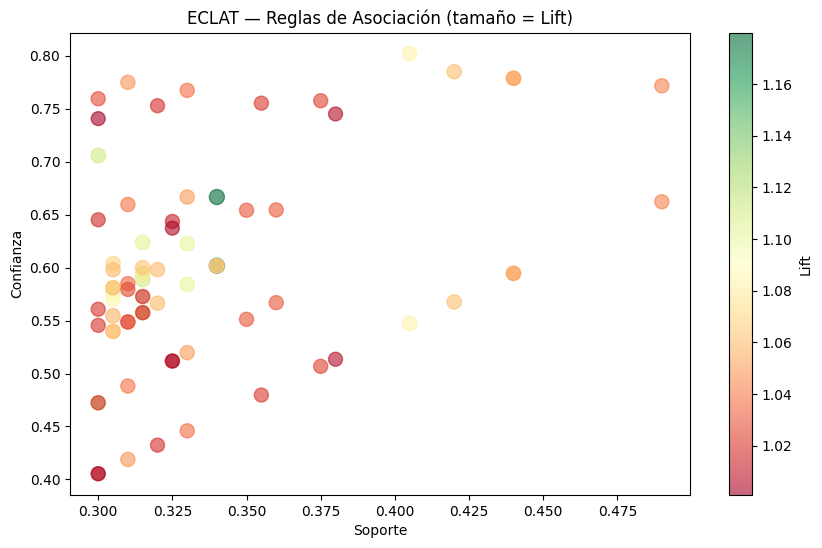

In [120]:
# Propósito: visualizar reglas con dispersión de soporte/confianza y tamaño por lift.
if not rules_df.empty:
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        rules_df["support"],
        rules_df["confidence"],
        s=rules_df["lift"] * 100,
        alpha=0.6,
        c=rules_df["lift"],
        cmap="RdYlGn",
    )
    plt.colorbar(scatter, label="Lift")
    plt.xlabel("Soporte")
    plt.ylabel("Confianza")
    plt.title("ECLAT — Reglas de Asociación (tamaño = Lift)")
    plt.show()
else:
    print("No hay reglas para visualizar en scatter.")

En esta celda se construye un mapa de calor con los valores de lift de las reglas más relevantes. El gráfico permite reconocer de forma directa qué combinaciones presentan relaciones más fuertes entre antecedente y consecuente.


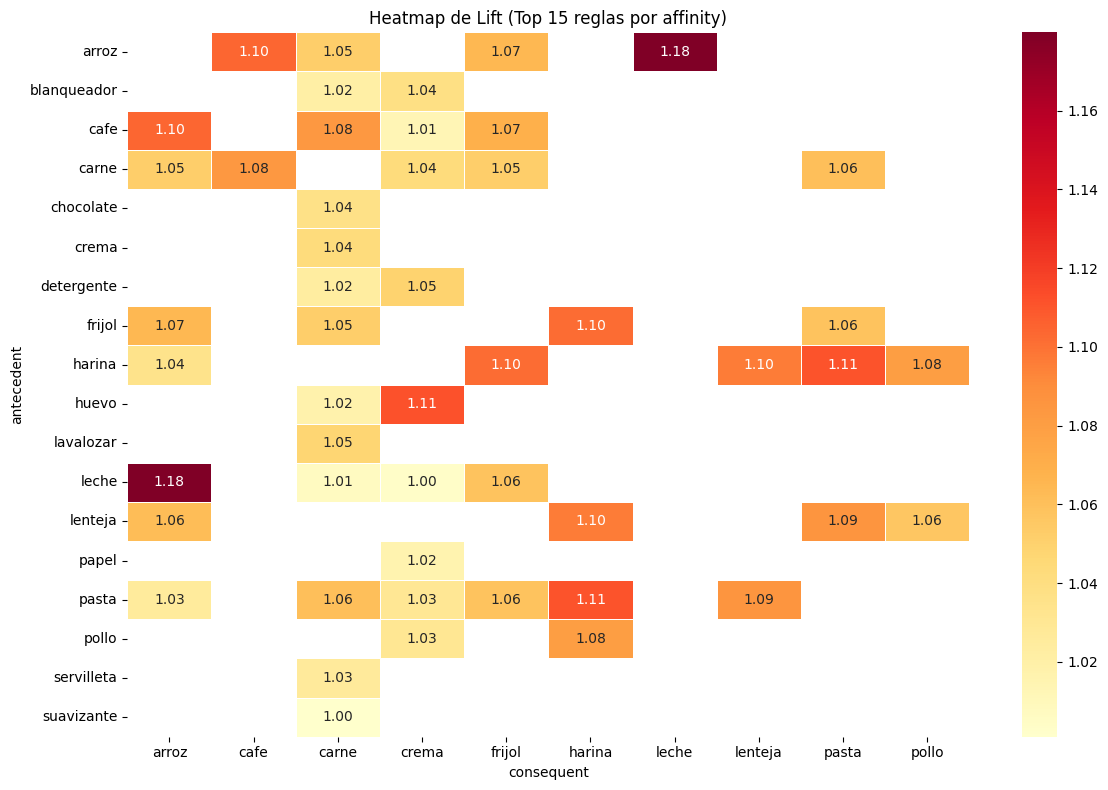

In [121]:
# Propósito: generar heatmap de lift para top reglas por affinity.
if not rules_df.empty:
    top_heat = rules_df.head(50)
    heat_df = top_heat.pivot_table(index='antecedent', columns='consequent', values='lift', aggfunc='mean')

    plt.figure(figsize=(12, 8))
    sns.heatmap(heat_df, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
    plt.title('Heatmap de Lift (Top 15 reglas por affinity)')
    plt.tight_layout()
    plt.show()
else:
    print('No hay reglas para visualizar en heatmap.')

En esta celda se representa una red de afinidad entre productos, donde el peso de las conexiones está asociado al lift. Esta visualización ayuda a entender la estructura global de las asociaciones dentro de la canasta de compra.


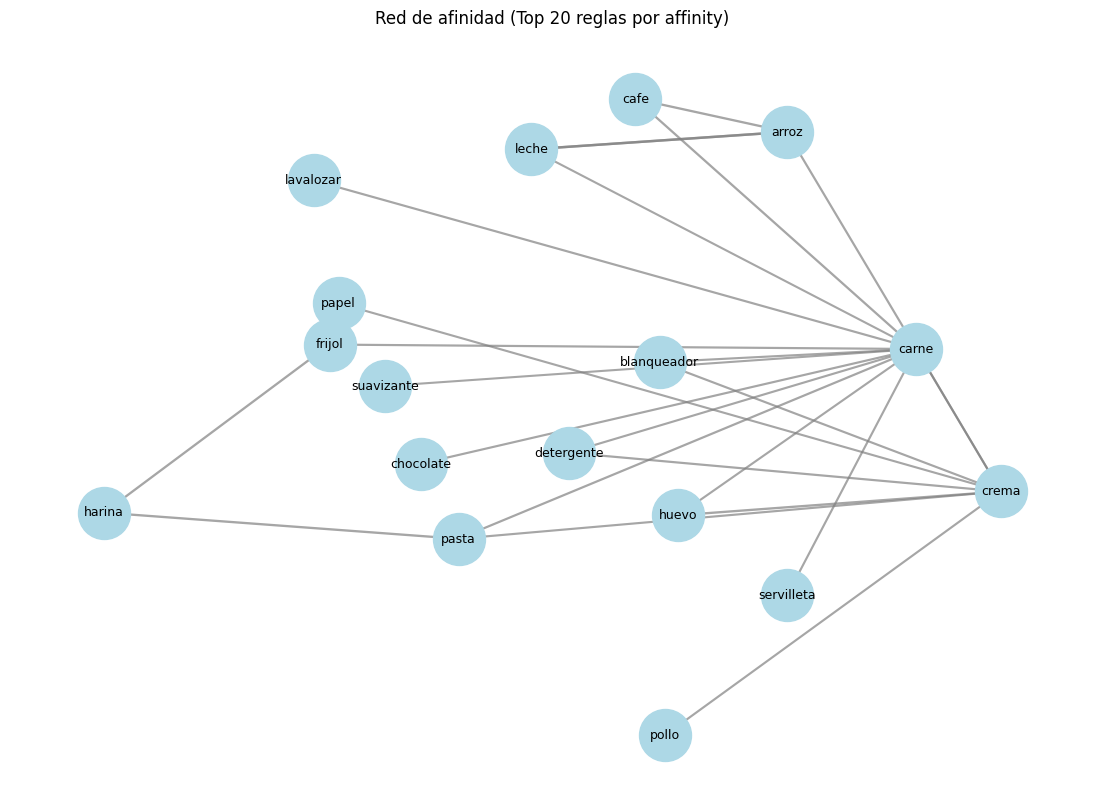

In [122]:
# Propósito: dibujar red de afinidad entre productos con pesos por lift.
if not rules_df.empty:
    top_net = rules_df.head(25)
    graph = nx.DiGraph()

    for _, row in top_net.iterrows():
        ant = row['antecedent']
        con = row['consequent']
        lift = row['lift']
        graph.add_edge(ant, con, weight=lift)

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(graph, seed=42)
    widths = [graph[u][v]['weight'] * 1.5 for u, v in graph.edges()]
    nx.draw_networkx_nodes(graph, pos, node_size=1400, node_color='lightblue')
    nx.draw_networkx_labels(graph, pos, font_size=9)
    nx.draw_networkx_edges(graph, pos, width=widths, edge_color='gray', arrows=True, alpha=0.7)
    plt.title('Red de afinidad (Top 20 reglas por affinity)')
    plt.axis('off')
    plt.show()
else:
    print('No hay reglas para visualizar en red de afinidad.')

En esta celda se muestran los productos más frecuentes para contextualizar la popularidad base de la canasta. Esta referencia es importante porque permite diferenciar entre reglas fuertes y productos simplemente comunes.


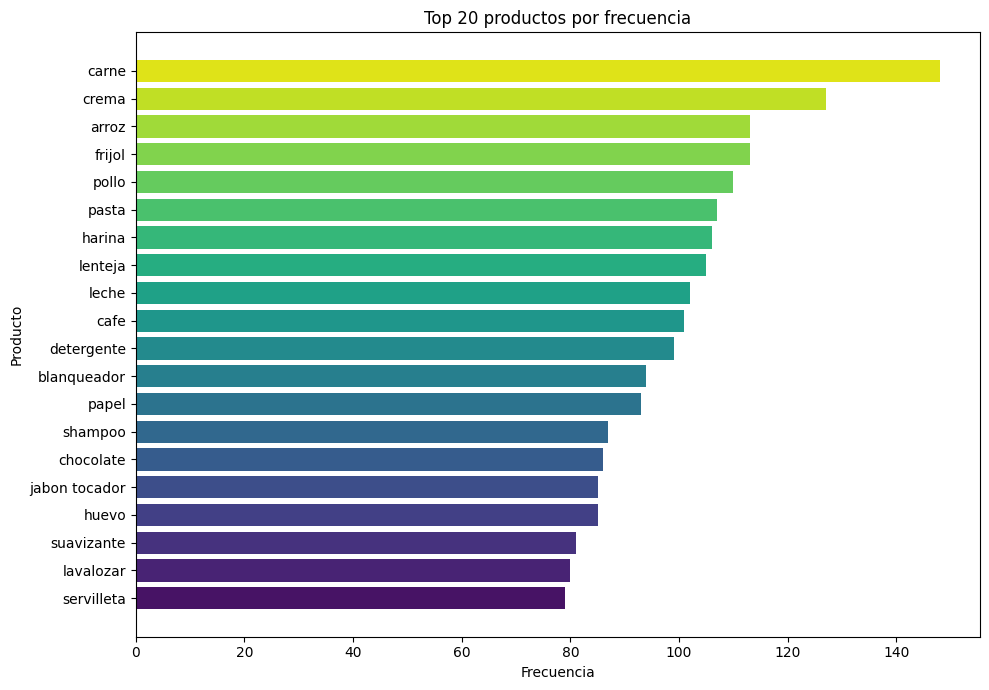

In [123]:
# Propósito: mostrar barras de frecuencia para top 20 productos.
product_freq = productos_df.sum().sort_values(ascending=False).head(20)
colors = sns.color_palette('viridis', n_colors=len(product_freq))

plt.figure(figsize=(10, 7))
plt.barh(product_freq.index[::-1], product_freq.values[::-1], color=colors)
plt.title('Top 20 productos por frecuencia')
plt.xlabel('Frecuencia')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

En esta celda se analiza la distribución de soporte, confianza y lift para evaluar la calidad global de las reglas. Esta revisión permite detectar si los resultados están concentrados en pocas reglas o si existe una estructura más equilibrada.


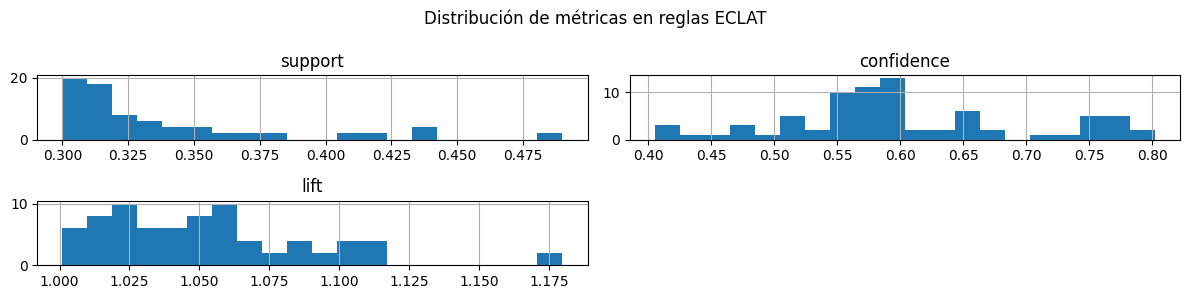

In [124]:
# Propósito: mostrar distribución de métricas de reglas (diagnóstico de calidad del modelo).
if not rules_df.empty:
    rules_df[['support', 'confidence', 'lift']].hist(figsize=(12, 3), bins=20)
    plt.suptitle('Distribución de métricas en reglas ECLAT')
    plt.tight_layout()
    plt.show()
else:
    print('No hay reglas para distribución de métricas.')

## 5. Interpretación

En esta fase se interpretan los resultados del modelo desde una perspectiva aplicada. Se compara el comportamiento de compra por estrato y por grupo de edad para traducir los patrones detectados en posibles decisiones de negocio.

### 5.1 Lectura por estrato NSE

En esta celda se ejecuta ECLAT por cada estrato y se calcula el soporte de los productos para comparar diferencias entre perfiles socioeconómicos. Esta comparación permite identificar patrones de compra específicos por segmento.


In [125]:
# Propósito: ejecutar ECLAT por estrato y construir comparativo de soporte por producto.
estrato_results: dict[str, pd.DataFrame] = {}
estrato_support_rows: list[pd.DataFrame] = []

for estrato in sorted(df_final['estrato_nse'].dropna().astype(str).unique()):
    subset = df_final[df_final['estrato_nse'].astype(str) == estrato]
    subset_freq, _, subset_products = run_eclat(subset, min_support=MIN_SUPPORT, max_len=MAX_ITEMSET)
    estrato_results[estrato] = subset_freq

    print(f'\nEstrato {estrato} | registros: {len(subset)}')
    display(subset_freq.head(5))

    product_support = (subset_products.sum() / max(len(subset_products), 1)).rename(estrato)
    estrato_support_rows.append(product_support.to_frame().T)

estrato_support_df = pd.concat(estrato_support_rows, axis=0).fillna(0)
common_top_10 = estrato_support_df.mean(axis=0).sort_values(ascending=False).head(10).index

[['agua', 'blanqueador', 'cafe', 'carne', 'colonia', 'detergente', 'dulce', 'frijol', 'fruta', 'galleta', 'gaseós', 'harina', 'jabon tocador', 'jamon', 'jugo', 'lavalozar', 'lenteja', 'loción', 'papas', 'papel', 'pasta', 'perfumir', 'shampoo', 'suavizante'], ['acondicionador', 'crema', 'desinfectante', 'frijol', 'fruta', 'gaseós', 'hilo', 'huevo', 'leche', 'lenteja', 'papel', 'pasta', 'queso'], ['acondicionador', 'ambientador', 'atun', 'carne', 'chocolate', 'crema', 'frijol', 'gaseós', 'harina', 'helado', 'hilo', 'huevo', 'jabon tocador', 'lavalozar', 'leche', 'limpiavidrio', 'pasta', 'perfumir', 'pollo', 'queso', 'salchicha', 'suavizante', 'tú'], ['arroz', 'azucar', 'carne', 'crema', 'detergente', 'galleta', 'harina', 'lavalozar', 'limpiavidrio', 'papel', 'perfumir', 'sal', 'salsa', 'shampoo', 'tú', 'vino'], ['acondicionador', 'agua', 'arroz', 'cafe', 'carne', 'desinfectante', 'desodorant', 'detergente', 'enjuagar', 'garbanzo', 'lenteja', 'papas'], ['agua', 'arroz', 'cafe', 'carne', '

,itemset,support
0,frozenset({carne}),0.7143
1,frozenset({harina}),0.7143
2,frozenset({acondicionador}),0.5714
3,"frozenset({harina, lavalozar, carne})",0.5714
4,"frozenset({gaseós, frijol, pasta})",0.5714


[['atun', 'blanqueador', 'colonia', 'desinfectante', 'lavalozar', 'leche', 'lenteja', 'loción', 'papel', 'pasta', 'suavizante', 'talco', 'tú'], ['blanqueador', 'cafe', 'carne', 'cera', 'chocolate', 'colonia', 'desodorant', 'detergente', 'harina', 'huevo', 'jamon', 'lavalozar', 'limpiapiso', 'loción', 'pasta', 'perfumir', 'pollo', 'salchicha', 'servilleta', 'shampoo'], ['acondicionador', 'agua', 'arroz', 'azucar', 'cafe', 'cera', 'colonia', 'crema', 'desinfectante', 'detergente', 'frijol', 'huevo', 'leche', 'loción', 'pescado', 'suavizante'], ['agua', 'ambientador', 'arroz', 'cafe', 'carne', 'chocolate', 'colonia', 'dulce', 'frijol', 'galleta', 'huevo', 'jamon', 'lavalozar', 'lenteja', 'limpiapiso', 'limpiavidrio', 'loción', 'otro', 'panelar', 'papas', 'papel', 'pasta', 'queso', 'salchicha', 'suavizante', 'talco', 'tú'], ['acondicionador', 'agua', 'ambientador', 'blanqueador', 'cafe', 'carne', 'cera', 'crema', 'harina', 'huevo', 'jabon tocador', 'jamon', 'jugo', 'leche', 'papas', 'pesca

,itemset,support
0,frozenset({carne}),0.72
1,frozenset({crema}),0.62
2,frozenset({arroz}),0.58
3,frozenset({pollo}),0.58
4,frozenset({leche}),0.54


[['acondicionador', 'blanqueador', 'cafe', 'carne', 'frijol', 'fruta', 'jabon tocador', 'jamon', 'limpiapiso', 'limpiavidrio', 'pan', 'pasta', 'pescado', 'pollo', 'salsa', 'shampoo', 'talco'], ['acondicionador', 'arroz', 'atun', 'blanqueador', 'carne', 'cera', 'crema', 'detergente', 'gaseós', 'huevo', 'jabon tocador', 'leche', 'otro', 'papel', 'pasta', 'servilleta', 'suavizante'], ['arroz', 'blanqueador', 'cafe', 'carne', 'cera', 'colonia', 'desinfectante', 'detergente', 'frijol', 'harina', 'hilo', 'jabon tocador', 'leche', 'lenteja', 'loción', 'pan', 'pasta', 'perfumir', 'pollo', 'proteccion', 'salsa', 'servilleta'], ['aceite', 'agua', 'ambientador', 'blanqueador', 'cera', 'cerveza', 'crema', 'desinfectante', 'enjuagar', 'huevo', 'jabon tocador', 'lavalozar', 'lenteja', 'pollo', 'proteccion', 'queso', 'salsa', 'shampoo', 'suavizante'], ['arroz', 'blanqueador', 'cafe', 'carne', 'cera', 'chocolate', 'dulce', 'fruta', 'galleta', 'garbanzo', 'harina', 'hilo', 'jabon tocador', 'leche', 'le

,itemset,support
0,frozenset({carne}),0.7368
1,frozenset({crema}),0.6842
2,frozenset({frijol}),0.5895
3,frozenset({cafe}),0.5895
4,frozenset({harina}),0.5895


[['agua', 'carne', 'cera', 'crema', 'detergente', 'enjuagar', 'galleta', 'garbanzo', 'jabon tocador', 'lenteja', 'limpiavidrio', 'panelar', 'pasta', 'perfumir', 'pollo', 'queso', 'salchicha', 'shampoo', 'suavizante', 'tú'], ['acondicionador', 'agua', 'ambientador', 'arroz', 'blanqueador', 'cafe', 'carne', 'cereal', 'cerveza', 'crema', 'desinfectante', 'detergente', 'dulce', 'frijol', 'garbanzo', 'harina', 'hilo', 'jabon tocador', 'jamon', 'leche', 'lenteja', 'limpiapiso', 'otro', 'panelar', 'papas', 'pasta', 'perfumir', 'pollo', 'proteccion', 'queso', 'salchicha', 'servilleta', 'suavizante', 'talco', 'tú', 'vino'], ['atun', 'blanqueador', 'cafe', 'carne', 'chocolate', 'colonia', 'detergente', 'gaseós', 'huevo', 'jabon tocador', 'lavalozar', 'leche', 'lenteja', 'loción', 'perfumir', 'pescado', 'servilleta', 'suavizante', 'talco', 'tú'], ['agua', 'arroz', 'cafe', 'desinfectante', 'detergente', 'helado', 'hilo', 'huevo', 'jabon tocador', 'jugo', 'leche', 'proteccion', 'sal'], ['arroz', 'b

,itemset,support
0,frozenset({carne}),0.7708
1,frozenset({frijol}),0.6875
2,frozenset({blanqueador}),0.6250
3,frozenset({crema}),0.5833
4,"frozenset({frijol, carne})",0.5625


### 5.2 Visualización comparativa por estrato

Esta celda muestra de forma gráfica cómo cambia el soporte de los productos principales entre estratos. La visualización facilita explicar diferencias de consumo y priorizar acciones segmentadas.

En esta celda se visualiza el soporte de los productos más representativos por estrato NSE. Este resultado ayuda a comunicar de manera simple qué productos dominan en cada segmento.


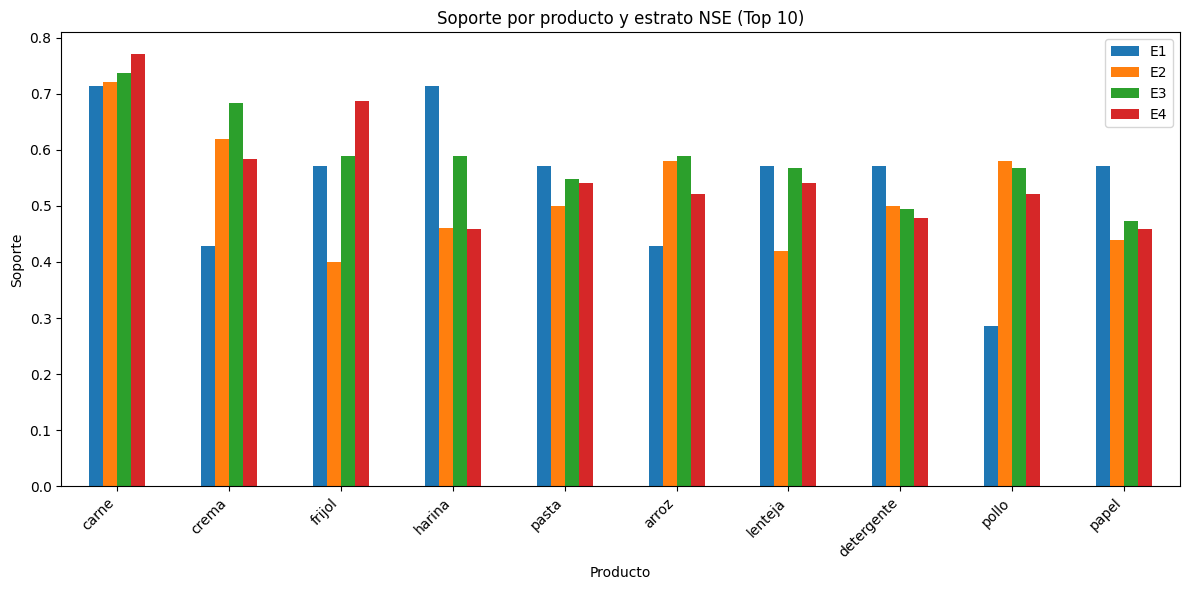

In [126]:
# Propósito: visualizar soporte de top productos por estrato NSE.
estrato_plot_df = estrato_support_df[common_top_10].T
estrato_plot_df.plot(kind='bar', figsize=(12, 6))
plt.title('Soporte por producto y estrato NSE (Top 10)')
plt.xlabel('Producto')
plt.ylabel('Soporte')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.3 Lectura por grupo de edad

En esta sección se compara la canasta de compra entre grupos etarios para identificar diferencias asociadas al ciclo de vida. El objetivo es reconocer variaciones que puedan orientar estrategias de surtido, promoción o comunicación diferenciada.

En esta celda se ejecuta ECLAT para cada grupo de edad y se comparan soportes de productos. Este análisis permite observar cómo cambian los patrones de compra según la etapa de vida.


In [127]:
# Propósito: ejecutar ECLAT por grupo etario y comparar soportes de productos.
edad_results: dict[str, pd.DataFrame] = {}
edad_support_rows: list[pd.DataFrame] = []

for grupo in df_final['grupo_edad'].dropna().astype(str).unique():
    subset = df_final[df_final['grupo_edad'].astype(str) == grupo]
    subset_freq, _, subset_products = run_eclat(subset, min_support=MIN_SUPPORT, max_len=MAX_ITEMSET)
    edad_results[grupo] = subset_freq

    print(f'\nGrupo {grupo} | registros: {len(subset)}')
    display(subset_freq.head(5))

    product_support = (subset_products.sum() / max(len(subset_products), 1)).rename(grupo)
    edad_support_rows.append(product_support.to_frame().T)

edad_support_df = pd.concat(edad_support_rows, axis=0).fillna(0)
common_age_top_10 = edad_support_df.mean(axis=0).sort_values(ascending=False).head(10).index

top_por_grupo = {
    grupo: soportes.sort_values(ascending=False).head(10).index.tolist()
    for grupo, soportes in edad_support_df.iterrows()
}
print('Top productos por grupo etario:')
display(pd.DataFrame.from_dict(top_por_grupo, orient='index').T)

[['atun', 'blanqueador', 'colonia', 'desinfectante', 'lavalozar', 'leche', 'lenteja', 'loción', 'papel', 'pasta', 'suavizante', 'talco', 'tú'], ['arroz', 'atun', 'blanqueador', 'cafe', 'carne', 'colonia', 'crema', 'frijol', 'galleta', 'garbanzo', 'harina', 'hilo', 'huevo', 'jabon tocador', 'jamon', 'limpiapiso', 'loción', 'otro', 'panelar', 'papel', 'pasta', 'pescado', 'pollo', 'queso', 'shampoo', 'suavizante'], ['agua', 'carne', 'cera', 'crema', 'detergente', 'enjuagar', 'galleta', 'garbanzo', 'jabon tocador', 'lenteja', 'limpiavidrio', 'panelar', 'pasta', 'perfumir', 'pollo', 'queso', 'salchicha', 'shampoo', 'suavizante', 'tú'], ['agua', 'arroz', 'atun', 'blanqueador', 'carne', 'chocolate', 'detergente', 'dulce', 'enjuagar', 'frijol', 'garbanzo', 'harina', 'hilo', 'huevo', 'jabon tocador', 'jugo', 'leche', 'lenteja', 'panelar', 'papel', 'pasta', 'pescado', 'pollo', 'proteccion', 'servilleta', 'shampoo'], ['arroz', 'atun', 'blanqueador', 'cafe', 'carne', 'chocolate', 'detergente', 'fr

,itemset,support
0,frozenset({carne}),0.80
1,frozenset({pollo}),0.75
2,frozenset({frijol}),0.70
3,"frozenset({pollo, carne})",0.65
4,frozenset({crema}),0.60


[['acondicionador', 'blanqueador', 'cafe', 'carne', 'frijol', 'fruta', 'jabon tocador', 'jamon', 'limpiapiso', 'limpiavidrio', 'pan', 'pasta', 'pescado', 'pollo', 'salsa', 'shampoo', 'talco'], ['acondicionador', 'arroz', 'atun', 'blanqueador', 'carne', 'cera', 'crema', 'detergente', 'gaseós', 'huevo', 'jabon tocador', 'leche', 'otro', 'papel', 'pasta', 'servilleta', 'suavizante'], ['arroz', 'blanqueador', 'cafe', 'carne', 'cera', 'colonia', 'desinfectante', 'detergente', 'frijol', 'harina', 'hilo', 'jabon tocador', 'leche', 'lenteja', 'loción', 'pan', 'pasta', 'perfumir', 'pollo', 'proteccion', 'salsa', 'servilleta'], ['aceite', 'agua', 'ambientador', 'blanqueador', 'cera', 'cerveza', 'crema', 'desinfectante', 'enjuagar', 'huevo', 'jabon tocador', 'lavalozar', 'lenteja', 'pollo', 'proteccion', 'queso', 'salsa', 'shampoo', 'suavizante'], ['arroz', 'blanqueador', 'cafe', 'carne', 'cera', 'chocolate', 'dulce', 'fruta', 'galleta', 'garbanzo', 'harina', 'hilo', 'jabon tocador', 'leche', 'le

,itemset,support
0,frozenset({carne}),0.7471
1,frozenset({crema}),0.6322
2,frozenset({arroz}),0.5747
3,frozenset({frijol}),0.5575
4,frozenset({harina}),0.5460


[['acondicionador', 'atun', 'blanqueador', 'cafe', 'carne', 'chocolate', 'crema', 'detergente', 'galleta', 'hilo', 'huevo', 'jabon tocador', 'lavalozar', 'lenteja', 'papel', 'pasta', 'pollo', 'suavizante', 'talco']]

Grupo 31-60 | registros: 1


,itemset,support
0,frozenset({acondicionador}),1.0
1,"frozenset({lavalozar, carne, talco})",1.0
2,"frozenset({lavalozar, suavizante, carne})",1.0
3,"frozenset({pollo, lavalozar, carne})",1.0
4,"frozenset({lavalozar, carne, pasta})",1.0


[['acondicionador', 'crema', 'desinfectante', 'frijol', 'fruta', 'gaseós', 'hilo', 'huevo', 'leche', 'lenteja', 'papel', 'pasta', 'queso'], ['arroz', 'atun', 'blanqueador', 'cafe', 'carne', 'colonia', 'crema', 'detergente', 'hilo', 'lenteja', 'loción', 'papas', 'pasta', 'salchicha', 'talco'], ['acondicionador', 'blanqueador', 'cera', 'chocolate', 'desinfectante', 'frijol', 'leche', 'limpiapiso', 'pollo', 'sal', 'salchicha', 'shampoo', 'suavizante'], ['acondicionador', 'atun', 'blanqueador', 'chocolate', 'crema', 'detergente', 'hilo', 'papel', 'pasta', 'pollo', 'poncar', 'suavizante', 'talco', 'tú', 'vino'], ['agua', 'arroz', 'blanqueador', 'cafe', 'chocolate', 'crema', 'desinfectante', 'detergente', 'galleta', 'gaseós', 'hilo', 'huevo', 'jabon tocador', 'leche', 'lenteja', 'limpiavidrio', 'papel', 'pollo', 'proteccion', 'queso', 'salsa']]

Grupo 26-30 | registros: 5


,itemset,support
0,frozenset({blanqueador}),0.8
1,"frozenset({crema, hilo})",0.8
2,frozenset({hilo}),0.8
3,frozenset({crema}),0.8
4,frozenset({acondicionador}),0.6


Top productos por grupo etario:


,Menor de 18,18-25,31-60,26-30
0,carne,carne,acondicionador,blanqueador
1,pollo,crema,carne,hilo
2,frijol,arroz,cafe,crema
3,crema,frijol,blanqueador,acondicionador
4,blanqueador,harina,atun,desinfectante
5,shampoo,pasta,galleta,chocolate
6,harina,lenteja,detergente,detergente
7,arroz,pollo,crema,leche
8,cafe,leche,hilo,pollo
9,jabon tocador,cafe,chocolate,papel


### 5.4 Visualización comparativa por grupo de edad

Esta visualización resume el soporte de los productos más representativos en cada grupo de edad. Su lectura facilita explicar de manera clara cuáles categorías son más fuertes en cada cohorte.

En esta celda se visualiza el soporte de los productos principales por grupo etario. Este resultado ayuda a comparar de forma directa los patrones entre jóvenes, adultos jóvenes, adultos y seniors.


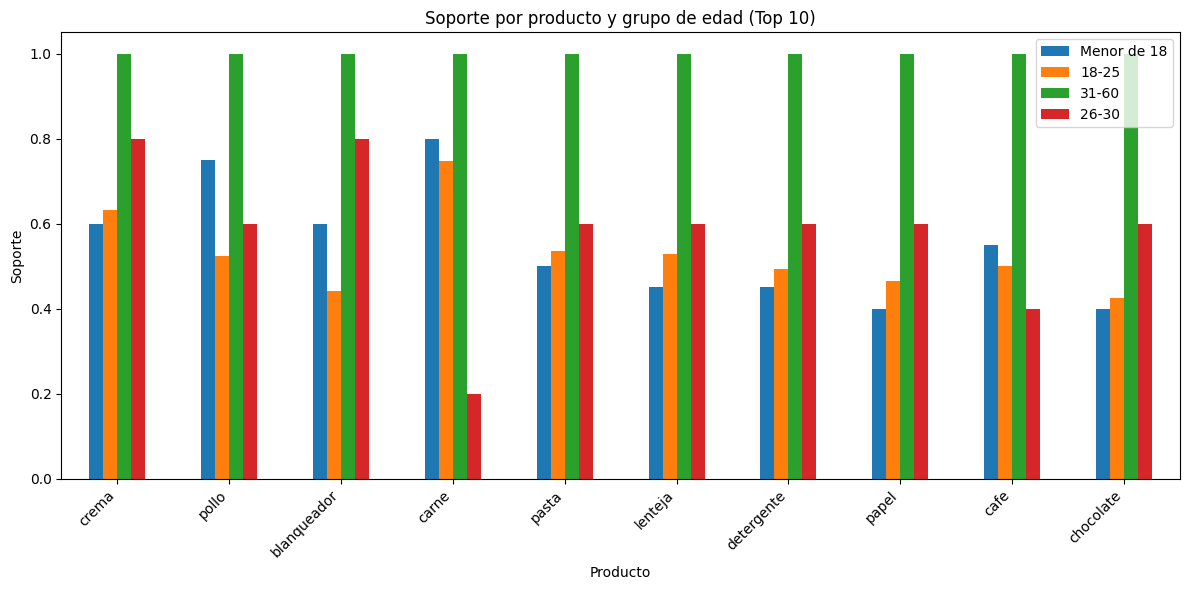

In [128]:
# Propósito: visualizar soporte de top productos por grupo de edad.
edad_plot_df = edad_support_df[common_age_top_10].T
edad_plot_df.plot(kind='bar', figsize=(12, 6))
plt.title('Soporte por producto y grupo de edad (Top 10)')
plt.xlabel('Producto')
plt.ylabel('Soporte')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Cierre de la implementación

Con esta organización, el notebook queda alineado con la secuencia metodológica solicitada: carga y descripción de datos, preprocesamiento, implementación del modelo, resultados e interpretación. En la parte de resultados se presentan reglas relevantes con soporte, confianza y lift, y en la parte de interpretación se traducen los patrones encontrados en decisiones aplicables a un contexto real. El flujo completo mantiene coherencia técnica y claridad narrativa para sustentar la presentación de forma comprensible.